In [2]:
import os
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
import scipy
import datetime
import configparser

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator

import lidar_processor, era5_processor, plt_helper

plt.style.use('latex_default.mplstyle')

"""Constants"""
# omega = 7.292*10**(-5)
g = 9.80665
Rd = 287.06
cp = 3.5 * Rd
Re = 6371229 # m (Radius of Earth for GRIB2 format - applies to ERA5 on ML)
p0 = 101325

cap=Rd/cp
capi=1/cap
capp=1.-cap # Cv/Cp
cappi=1./capp # Cp/Cv
wexnr=Rd/(cp-Rd) # Rd/Cv
compri=Rd/p0**cap
# th00=tt00*(pr00/pref00)**(-cap)
# rh00=pr00/(rg*tt00)

def tf(zeta):
    return zeta*zeta*zeta*(10.-15.*zeta+6.*zeta*zeta)
def tfd(zeta):
    return 30.*zeta*zeta*(1.-2.*zeta+zeta*zeta)

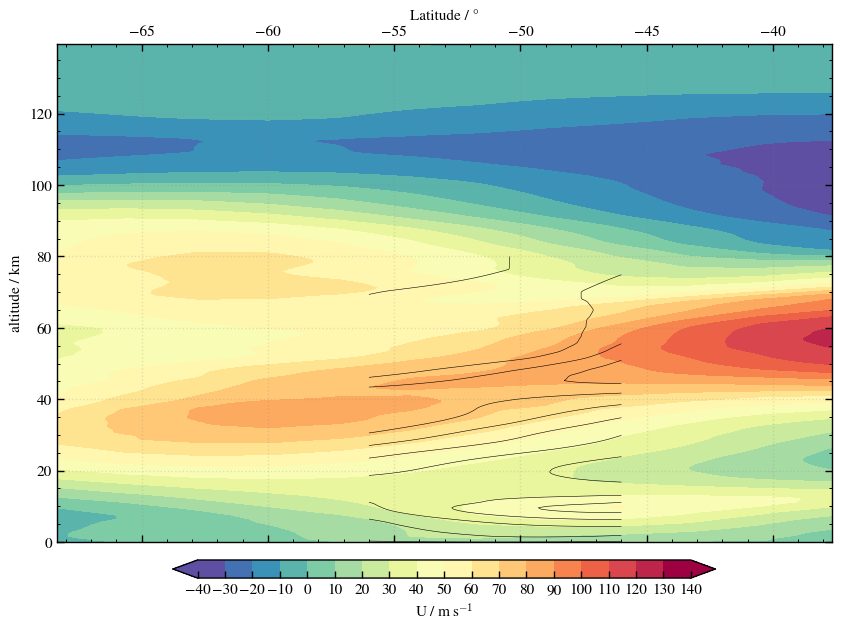

In [3]:
"""Meridional cross section"""
lats = slice(-56,-60)
lons = slice(280,284)
lon = 282 

ds        = xr.open_dataset("../data/eulag/era5_ml_T21_int.nc")
ds_jawara = xr.open_dataset(os.path.join("/export/data2/model/jawara/2018","jawara_patagonia_180616.nc"))
# ds = ds.sel(latitude=lats, longitude=lons)
# ds_jawara = ds_jawara.sel(lat=lats, lon=lons)

wind_levels = np.arange(-40,150,10)
cmap_wind = plt.get_cmap('Spectral_r')
norm_wind = BoundaryNorm(boundaries=wind_levels, ncolors=cmap_wind.N, clip=True)

gskw  = {'hspace':0.06, 'height_ratios': [5,1]} #  , 'width_ratios': [5,5]}
fig, axes = plt.subplots(2,1, figsize=(10,8), gridspec_kw=gskw)
ax0 = axes[0]
ax1 = axes[1]
ax1.axis('off')

contf = ax0.contourf(ds_jawara['latitude'].values, ds_jawara['level'].values/1000, ds_jawara['u'].mean(dim=["time"]).sel(longitude=lon, method="nearest").values, 
                                levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both') 
cont = ax0.contour(ds['latitude'].values, ds['level'].values/1000, ds['u'].mean(dim=["time"]).sel(longitude=lon, method="nearest").values, levels=wind_levels, colors='k', linewidths=0.4) # BW

ax0.yaxis.set_minor_locator(AutoMinorLocator()) 
ax0.xaxis.set_minor_locator(AutoMinorLocator())

ax0.xaxis.set_label_position('top')
ax0.tick_params(which='both', labelbottom=False,labeltop=True)
ax0.set_ylabel('altitude / km')
# ax0.set_ylim(vert_range_lid)
# ax0.set_xlim(ds_ml['time'].values[0],ds_ml['time'].values[-1])
ax0.set_xlabel("Latitude / °")
ax0.grid()
cbar = fig.colorbar(contf, ax=ax1, location='bottom', ticks=wind_levels, shrink=0.7, fraction=1, aspect=30)
cbar.set_label(r"U / m$\,$s$^{-1}$")


In [4]:
"""ERA5 or JAWARA background profile"""
ds        = xr.open_dataset("../data/eulag/era5_ml_T21_int.nc")
ds_jawara = xr.open_dataset(os.path.join("/export/data2/model/jawara/2018","jawara_patagonia_180616.nc"))

"""Reduce area"""
lats = slice(-56,-60)
lats = slice(-44,-50)
lons = slice(278,284)
ds = ds.sel(latitude=lats, longitude=lons)
ds_jawara = ds_jawara.sel(latitude=lats, longitude=lons)

ds['th']  = ds['t'] * (p0/ds['p'])**(2/7)

"""Smooth the field using a Gaussian filter"""
sigma_gauss = 4  # higher -> more smoothing
ds["th"].values = scipy.ndimage.gaussian_filter(ds["th"].values, sigma_gauss, axes=1) 

ds['rho'] = ds['p']**capp / (ds['th']*compri)
ds_jawara['rho'] = ds_jawara['p']**capp / (ds_jawara['th']*compri)
# ppe(i,j,k)=(rhe(i,j,k)*the(i,j,k)*compri)**cappi

# ds['N'] = (['time','level','latitude','longitude'], (g/ds['th'].values * np.gradient(ds['th'].values, ds['level'].values[1]-ds['level'].values[0], axis=1))**(1/2))
# i = np.arange(0,len(ds['level'])-1,1)
logth = np.log(ds['th'].values)
ds['N'] = (['time','level','latitude','longitude'], (g * np.gradient(logth, 400, axis=1))**(1/2))
# ds['N'][:,i,:,:] = (g * (logth[:,i+1,:,:]-logth[:,i,:,:]) / 400)**(1/2)

logth = np.log(ds_jawara['th'].values)
ds_jawara['N'] = (['time','level','latitude','longitude'], (g * np.gradient(logth, 400, axis=1))**(1/2))

# ds = ds.drop(["t","p"])

"""Average and trim"""
dsm = ds.mean(dim=["time","latitude","longitude"])
ds = ds.mean(dim=["latitude","longitude"])

dsm_jawara = ds_jawara.mean(dim=["time","latitude","longitude"])
ds_jawara = ds_jawara.mean(dim=["latitude","longitude"])

ds = ds_jawara
dsm = dsm_jawara

In [5]:
"""JAWARA data hourly grouping for one month"""
ds_jawara = xr.open_dataset(os.path.join("/export/data2/model/jawara/2018","jawara_coral_1806.nc"))

ds_jawara['rho'] = ds_jawara['p']**capp / (ds_jawara['th']*compri)
logth = np.log(ds_jawara['th'].values)
ds_jawara['N'] = (['time','level','latitude','longitude'], (g * np.gradient(logth, 400, axis=1))**(1/2))

"""Average and trim"""
dsm_jawara = ds_jawara.mean(dim=["time","latitude","longitude"])
ds_jawara = ds_jawara.mean(dim=["latitude","longitude"])
ds_jawara_h = ds_jawara.groupby('time.hour').mean()
ds_jawara_h

<xarray.Dataset>
Dimensions:  (level: 350, hour: 24)
Coordinates:
  * level    (level) int64 0 400 800 1200 1600 ... 138400 138800 139200 139600
  * hour     (hour) int64 0 1 2 3 4 5 6 7 8 9 ... 14 15 16 17 18 19 20 21 22 23
Data variables:
    u        (hour, level) float64 3.302 7.956 8.888 8.714 ... 13.77 13.96 14.14
    v        (hour, level) float64 -0.8494 -1.037 0.2955 ... 10.84 10.92 11.0
    p        (hour, level) float64 1.004e+05 9.555e+04 ... 0.000394 0.0003835
    t        (hour, level) float64 276.7 273.8 271.6 269.8 ... 568.1 571.8 575.6
    th       (hour, level) float64 276.4 277.4 279.1 ... 1.5e+05 1.518e+05
    rho      (hour, level) float64 1.268 1.22 1.17 ... 2.313e-09 2.242e-09
    N        (hour, level) float64 0.008372 0.009683 0.01224 ... 0.01724 0.01719

In [6]:
"""SAAMER winds hourly grouping for one month"""
saamer_file_path = "/export/data2/observations/saamer/SAAMER_Hindley22_version_2018.nc"

ds_saamer = xr.open_dataset(saamer_file_path)
base_date = datetime.datetime(2018,1,1,0,0)
datetime_index = [base_date + datetime.timedelta(days=int(ts), minutes=(ts-int(ts))*24*60) for ts in ds_saamer['time'].values]
ds_saamer = ds_saamer.assign_coords(time=datetime_index)

# - Average June conditions - # 
time_slc  = slice(datetime.datetime(2018,6,1,0,0), datetime.datetime(2018,7,1,0,0))
ds_saamer = ds_saamer.sel(time=time_slc)
ds_saamer_h = ds_saamer.groupby('time.hour').mean()
ds_saamer_h

<xarray.Dataset>
Dimensions:          (altitude: 30, hour: 24)
Coordinates:
  * altitude         (altitude) float64 76.0 77.0 78.0 ... 103.0 104.0 105.0
  * hour             (hour) int64 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23
Data variables:
    zonal_wind       (hour, altitude) float64 15.49 15.59 14.64 ... 11.2 13.24
    meridional_wind  (hour, altitude) float64 1.944 -1.075 ... 31.15 41.99
Attributes:
    data_source:        SAAMER
    category:           Ground-based Meteor Radar
    latitude:           -53.7
    longitude:          292.3
    date_last_revised:  2022-12-14
    created_by:         Neil Hindley
    comment:            Horizontal wind data determined by means of the Gauss...
    year:               2018
    surface_altitude:   21m

In [7]:
def plot_tide_timestamp(t, id0, ut, vt, ut_saamer, vt_saamer, ut_jamara, vt_jamara, levels, levels_saamer, levels_jawara, folder):
    fig, axes = plt.subplots(5, 2, figsize=(9, 10), gridspec_kw={'hspace': 0.06, 'wspace': 0.03, 'width_ratios': [5, 5], 'height_ratios': [2, 1.5, 10, 10, 15]})

    animation = False
    utctime0 = 11
    utctime1 = 16

    axes[0,0].axis('off')
    axes[0,1].axis('off')

    axes[1,0].axis('off')
    axes[1,1].axis('off')

    ax_u = axes[2,0]
    ax_v = axes[3,0]

    ax_uj = axes[2,1]
    ax_vj = axes[3,1]

    ax_wind = axes[-1,0]
    ax_rose = axes[-1,1]

    hours = np.arange(0,24,1)
    # wind_levels = np.arange(-50,75,5)
    wind_levels = np.arange(-70,75,5)
    wind_levels_cont = np.arange(-70,120,5)
    cmap_wind = plt.get_cmap('Spectral_r')
    # cmap_wind = plt.get_cmap('RdBu_r')
    norm_wind = BoundaryNorm(boundaries=wind_levels, ncolors=cmap_wind.N, clip=True)
    
    alt_range = [65,115]
    xrange = [0,23]
    # id0 = 16
    lwl = 2

    """Zonal wind"""
    contf = ax_u.contourf(hours, levels_saamer, ut_saamer.T, 
                                levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both') 
    cont = ax_u.contour(hours, levels/1000, ut[id0:id0+24,:].T, levels=wind_levels_cont, colors='k', linewidths=0.4) # BW

    ax_u.yaxis.set_minor_locator(AutoMinorLocator()) 
    ax_u.xaxis.set_minor_locator(AutoMinorLocator())

    ax_u.xaxis.set_label_position('top')
    ax_u.tick_params(which='both', labelbottom=False,labeltop=True)
    ax_u.set_ylabel('altitude / km')
    ax_u.set_ylim(alt_range)
    ax_u.set_xlabel("UTC hour of the day / -")
    if animation:
        ax_u.axvline(t-id0, ls="--", lw=lwl, color='k')
    else:
        ax_u.axvline(utctime0, ls="--", lw=lwl, color='k')
        ax_u.axvline(utctime1, ls="--", lw=lwl, color='k')
    ax_u.set_xlim(xrange)

    ax_u.text(0.97, 0.96, "-- Idealized", transform=ax_u.transAxes, 
                 verticalalignment='top', horizontalalignment='right',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})
    
    """Meridional wind"""
    contf = ax_v.contourf(hours, levels_saamer, vt_saamer.T, 
                                levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both') 
    cont = ax_v.contour(hours, levels/1000, vt[id0:id0+24,:].T, levels=wind_levels_cont, colors='k', linewidths=0.4) # BW

    ax_v.yaxis.set_minor_locator(AutoMinorLocator()) 
    ax_v.xaxis.set_minor_locator(AutoMinorLocator())

    ax_v.tick_params(which='both', labelbottom=False,labeltop=False)
    ax_v.set_ylabel('altitude / km')
    ax_v.set_ylim(alt_range)
    if animation:
        ax_v.axvline(t-id0, ls="--", lw=lwl, color='k')
    else:
        ax_v.axvline(utctime0, ls="--", lw=lwl, color='k')
        ax_v.axvline(utctime1, ls="--", lw=lwl, color='k')
    ax_v.set_xlim(xrange)

    cbar = fig.colorbar(contf, ax=axes[0,:], location='top', ticks=np.arange(-70,80,10), shrink=0.75, fraction=1, aspect=30)
    cbar.set_label(r"SAAMER wind / m$\,$s$^{-1}$")

    """JAWARA"""
    """Zonal wind (JAWARA)"""
    contf = ax_uj.contourf(hours, levels_saamer, ut_saamer.T, 
                                levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both') 
    cont = ax_uj.contour(hours, levels_jawara/1000, ut_jamara.T, levels=wind_levels_cont, colors='k', linewidths=0.4) # BW

    ax_uj.yaxis.set_minor_locator(AutoMinorLocator()) 
    ax_uj.xaxis.set_minor_locator(AutoMinorLocator())

    ax_uj.xaxis.set_label_position('top')
    ax_uj.tick_params(which='both', labelbottom=False,labeltop=True,labelleft=False)
    ax_uj.set_ylim(alt_range)
    ax_uj.set_xlabel("UTC hour of the day / -")
    if animation:
        ax_uj.axvline(t-id0, ls="--", lw=lwl, color='k')
    ax_uj.set_xlim(xrange)

    ax_uj.text(0.97, 0.96, "-- JAWARA", transform=ax_uj.transAxes, 
                 verticalalignment='top', horizontalalignment='right',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})

    """Meridional wind (JAWARA)"""
    contf = ax_vj.contourf(hours, levels_saamer, vt_saamer.T, 
                                levels=wind_levels, cmap=cmap_wind, norm=norm_wind, extend='both') 
    cont = ax_vj.contour(hours, levels_jawara/1000, vt_jamara.T, levels=wind_levels_cont, colors='k', linewidths=0.4) # BW

    ax_vj.yaxis.set_minor_locator(AutoMinorLocator()) 
    ax_vj.xaxis.set_minor_locator(AutoMinorLocator())
    ax_vj.tick_params(which='both', labelbottom=False,labeltop=False,labelleft=False)
    ax_vj.set_ylim(alt_range)
    if animation:
        ax_vj.axvline(t-id0, ls="--", lw=lwl, color='k')
    ax_vj.set_xlim(xrange)

    """Wind profile plot"""
    lwl = 2
    ax_wind.axvline(0, ls="-.", lw=1, color='grey')

    ax_wind.set_xlabel("(u,v) / m$\,$s$^{-1}$")
    ax_wind.set_ylabel("altitude z / km")
    ax_wind.set_xlim([-110, 110])
    ax_wind.set_ylim([0, 130])
    # ax_wind.xaxis.set_label_position('top')
    ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
    ax_wind.tick_params(which='both', top=True, right=True, bottom=True, left=True, 
                        labelbottom=True, labeltop=False, color="grey")
    ax_wind.grid()

    ax_wind.text(0.97, 0.96, f"UTC hour: {t-id0:02}", transform=ax_wind.transAxes, 
                 verticalalignment='top', horizontalalignment='right',
                 bbox={"boxstyle": "round", "lw": 0.67, "facecolor": "white", "edgecolor": "black"})
    

    """Wind rose plot"""
    ax_rose.remove()
    ax_rose = fig.add_subplot(5, 2, 10, projection='polar')

    altitudes = [80.e3, 90.e3, 100.e3]  # Altitudes at which to plot wind vectors
    ilevs = np.searchsorted(levels, altitudes)
    u_wind = ut[t,ilevs]
    v_wind = vt[t,ilevs]

    r = np.sqrt(u_wind**2 + v_wind**2)  # Wind speed (magnitude)
    theta = (90 - np.degrees(np.arctan2(v_wind, u_wind))) % 360
    
    ax_rose.set_theta_zero_location('N')  # Set 0° to point north
    ax_rose.set_theta_direction(-1) 
    
    cols = ["royalblue", "goldenrod", "firebrick"]
    for i in range(0,len(altitudes)):
        ax_rose.quiver(0,0, theta[i]*np.pi/180, r[i], angles='xy',
                       scale=1, scale_units='xy', width=0.02, headwidth=3, headlength=3.5, headaxislength=3, color=cols[i])
        ax_wind.axhline(altitudes[i]/1000, ls="--", lw=lwl, color=cols[i])

        # print("col: ", cols[i])
        # print("u: ", u_wind[i].values)
        # print("v: ", v_wind[i].values)
        # print("Theta: ", theta[i].values)
        # print("R: ", r[i].values)

    ax_rose.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
    ax_rose.set_xticklabels(['N','NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']) 
    ax_rose.set_rlim(0, 60)
    ax_rose.set_rticks([20,40],labels=[20,"40$\,$ms$^{-1}$"])  # Hide the radial ticks
    ax_rose.set_rlabel_position(1/24*360) 
    ax_rose.tick_params(axis="x",direction="in", pad=-17)
    ax_rose.grid(True)        

    if animation:
        ax_wind.plot(ut[t,:], levels/1000, lw=lwl, ls='-',  color="black", label="u")
        ax_wind.plot(vt[t,:], levels/1000, lw=lwl, ls='--', color="black", label="v")
    else:
        ax_wind.plot(ut[utctime0+id0,:], levels/1000, lw=lwl, ls='-',  color="black", label="u")
        ax_wind.plot(ut[utctime1+id0,:], levels/1000, lw=lwl, ls='dotted',  color="black")
        ax_wind.plot(vt[utctime0+id0,:], levels/1000, lw=lwl, ls='--', color="black", label="v")
        # ax_wind.plot(vt[utctime1+id0,:], levels/1000, lw=lwl, ls='dotted', color="black")
    ax_wind.legend(loc="lower left")

    """Labels / Numbering"""
    numb_str = ['a','b','c','d','e','f','g','h']
    ypp = 0.93
    xpp = 0.05
    k=0
    for i in range(2,4):
        axes[i,0].text(xpp, ypp, numb_str[2*k], transform=axes[i,0].transAxes, verticalalignment='top', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        axes[i,1].text(xpp, ypp, numb_str[2*k+1], transform=axes[i,1].transAxes, verticalalignment='top', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        k=k+1
    axes[4,0].text(xpp, 0.96, numb_str[4], transform=axes[4,0].transAxes, verticalalignment='top', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax_rose.text(7/4*np.pi, 80, numb_str[5], verticalalignment='top', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})


    """Save figure"""
    os.makedirs(folder, exist_ok=True)
    if animation:   
        fig_name = 'tide_' + '{:02d}'.format(t) + '.png'
    else:
        fig_name = 'tide_phases.png'
    fig.savefig(os.path.join(folder, fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight')

Array legth:  321 Max Alt:  128000


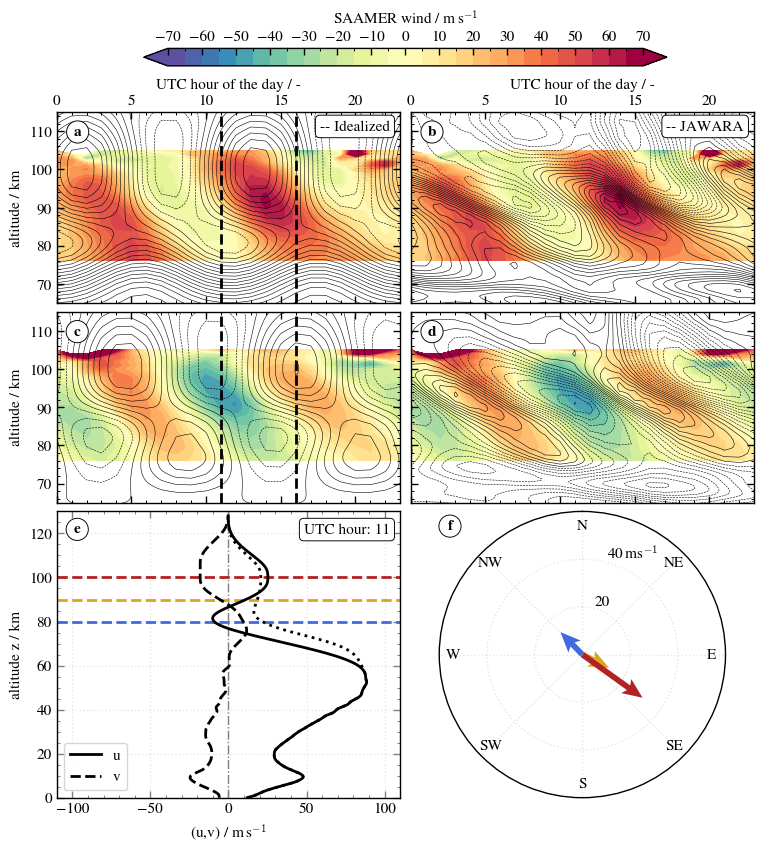

In [8]:
"""Pad wind profiles at upper boundary"""
# total = 320
icut = 135
npad = 185
icutv = 150
npadv = 170
vres = ds['level'].values[1]-ds['level'].values[0]
u  = np.concatenate((dsm['u'].values[:icut+1], dsm['u'].values[icut] * np.ones(npad)))
v  = np.concatenate((dsm['v'].values[:icutv+1], dsm['v'].values[icutv] * np.ones(npadv)))

levels = np.arange(0, len(v)*vres, vres)
levels_pad= levels[-npad:]
print("Array legth: ", len(levels), "Max Alt: ", levels[-1])


def tide_range(levels, zt0, zt1, zt2):
    r1 = np.where((levels>zt0) & (levels<=zt1), tf((levels-zt0)/(zt1-zt0)), 0)
    r2 = np.where((levels>zt1) & (levels<=zt2), 1-tf((levels-zt1)/(zt2-zt1)), 0)
    r3 = r1 + r2
    return r3

"""Base wind profile"""
zcut0 = levels[icut]
zcut1 = 87.e3
zcut2 = 105.e3
zcut3 = 128.e3
u00 = 108 # depends on PNJ maximum
u01 = 20
r00 = np.where((levels>zcut0), tf((levels-zcut0)/(zcut1-zcut0)), 0)
r00 = np.where(levels>zcut1, 1, r00)
r01 = np.where((levels>zcut2), tf((levels-zcut2)/(zcut3-zcut2)), 0)
u = u-u00*r00 + u01*r01
u = np.where((levels>zcut3), 0, u) 
u = scipy.ndimage.gaussian_filter(u, 1, axes=0) 

zcut0v = levels[icutv]
r00 = np.where((levels>zcut0v), tf((levels-zcut0v)/(zcut1-zcut0v)), 0)
r00 = np.where(levels>zcut1, 1, r00)
v00 = 20
v01 = 19
v = v-v00*r00 + v01*r01
v = np.where((levels>zcut3), 0, v) 
v = scipy.ndimage.gaussian_filter(v, 1, axes=0) 

"""Tide layers"""
# u_amp_0 = 30
# zt00=55.e3 
# zt01=75.e3
# zt02=85.e3
# r0 = tide_range(levels,zt00, zt01, zt02)

uamp1 = 40
zt10=56.e3 
zt11=75.e3
zt12=100.e3

uamp2 = 70
zt20=75.e3 
zt21=100.e3
zt22=zcut3

uamp3 = 40
zt30=62.e3 
zt31=80.e3
zt32=100.e3

uamp4 = 55
zt40=80.e3 
zt41=100.e3
zt42=zt22

r1u = tide_range(levels,zt10, zt11, zt12)
r2u = tide_range(levels,zt20, zt21, zt22)
r3u = tide_range(levels,zt30, zt31, zt32)
r4u = tide_range(levels,zt40, zt41, zt42)


"""Temporal component of tide u(t,z)"""
def ftide(zetai, phase=0, nlayers=321):
    pi = np.pi
    zetai = zetai - phase
    zetai = np.where(zetai>0, zetai, 0)
    # ftide = np.abs(np.sin(pi*zetai))
    ftide = np.sin(pi*zetai)**2
    # ftide0 = np.cos(pi*zetai0-pi/2)**2
    return np.tile(ftide, (nlayers,1)).T

Ttide = 12
zetai = np.linspace(0,24,24) / Ttide
zetai = np.linspace(0,48,48) / Ttide

# - Phase shift in fraction of period - #
# phase0 = 0.5
# ftide_u0 = ftide(zetai, phase=phase0)

ftide_u1 = ftide(zetai, phase=0.35)
ftide_v1 = ftide(zetai, phase=0.6)

ftide_u2 = ftide(zetai, phase=0)
ftide_v2 = ftide(zetai, phase=0.25)

ut = u + ftide_u2*uamp2*r2u + ftide_u1*uamp1*r1u # + ftide_u0*u_amp_0*r0
vt = v + ftide_v2*uamp4*r4u + ftide_v1*uamp3*r3u
 
"""Define phase 0 and phase 1"""
id0 = 16
utctime0 = 11+id0
utctime1 = 16+id0
uphase0 = ut[utctime0,:]
uphase1 = ut[utctime1,:]
vphase0 = vt[utctime0,:]
vphase1 = vt[utctime1,:]

folder   = "../data/eulag/figures/2D-tide"
plot_tide_timestamp(utctime0, id0, ut, vt, ds_saamer_h['zonal_wind'].values, ds_saamer_h['meridional_wind'].values, ds_jawara_h['u'].values, ds_jawara_h['v'].values, levels, ds_saamer_h['altitude'].values, ds_jawara_h['level'].values, folder)

In [55]:
%%capture
folder   = "../data/eulag/figures/2D-tide"
# import shutil
# shutil.rmtree(folder)

#for t in range(np.shape(ut)[0]):
for t in range(16,16+24):
    plot_tide_timestamp(t, 16, ut, vt, ds_saamer_h['zonal_wind'].values, ds_saamer_h['meridional_wind'].values, 
                        ds_jawara_h['u'].values, ds_jawara_h['v'].values, 
                        levels, ds_saamer_h['altitude'].values, ds_jawara_h['level'].values, folder)
plt_helper.create_animation(folder,os.path.join(folder,"2D-tide.mp4"),fps=6)

In [9]:
"""Pad other ERA5 profiles at upper boundary"""
icut = 170
npad = 150
levels_pad= levels[-npad:]
print("Array legth: ", len(levels), "Max Alt: ", levels[-1])

th_slc = slice(150,170)
# coefficients_th = np.polyfit(dsm['level'].values[th_slc], dsm['th'].values[th_slc], 2)
coefficients_th = np.polyfit(dsm['level'].values[th_slc], np.log(dsm['th'].values[th_slc]), 1)
th_pad = np.polyval(coefficients_th, levels_pad)
th = np.concatenate((dsm['th'].values[:icut+1], np.exp(th_pad)))
N  = (g/th * np.gradient(th, vres))**(1/2)

rho_slc = slice(150,170)
# coefficients_rho = np.polyfit(ds['level'].values[rho_slc], dsm['rho'].values[rho_slc], 2)
coefficients_rho = np.polyfit(ds['level'].values[rho_slc], np.log(dsm['rho'].values[rho_slc]), 1)
rho_pad = np.polyval(coefficients_rho, levels_pad)
rho = np.concatenate((dsm['rho'].values[:icut+1], np.exp(rho_pad)))

temp = th*(rho*Rd*th/p0)**(Rd/(cp-Rd)) # + 273.15 # 

Array legth:  321 Max Alt:  128000


In [10]:
"""Get JAWARA profiles for EULAG vertical grid"""
l = 321
th = dsm['th'].values[0:l]
rho = dsm['rho'].values[0:l]
p = dsm['p'].values[0:l]
N  = (g/th * np.gradient(th, vres))**(1/2)
temp = th*(rho*Rd*th/p0)**(Rd/(cp-Rd))

uphase0 = uphase0[0:l]
vphase0 = vphase0[0:l]
uphase1 = uphase1[0:l]
vphase1 = vphase1[0:l]

/tmp/ipykernel_11086/1571788626.py:104: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.savefig(os.path.join(folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'
/athome/bind_mc/miniforge3/envs/unstable-venv/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: AutoMinorLocator does not work with logarithmic scale
  func(*args, **kwargs)
/athome/bind_mc/miniforge3/envs/unstable-venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: AutoMinorLocator does not work with logarithmic scale
  fig.canvas.print_figure(bytes_io, **kw)


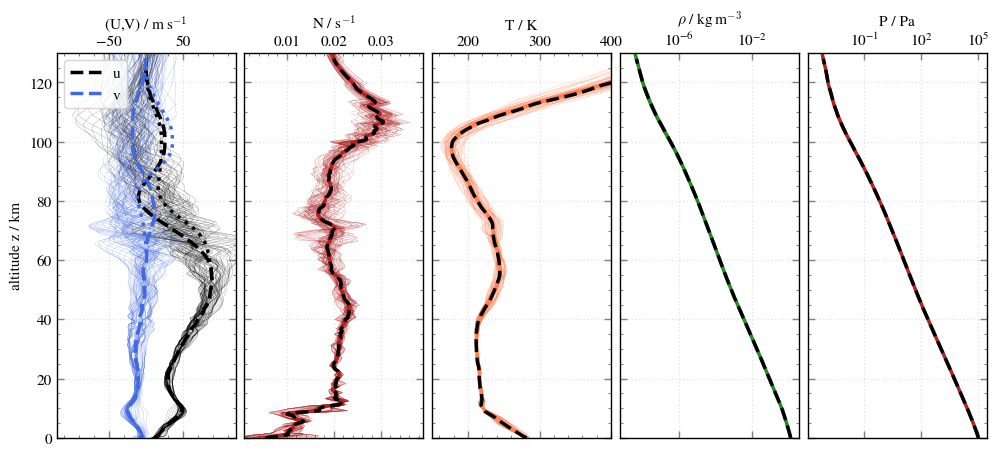

In [11]:
"""Vis env"""
# fig, ax = plt.subplots(1,1, figsize=(6,6), subplot_kw={'projection': ccrs.LambertConformal()})
fig, axes = plt.subplots(1,5, figsize=(12,5),sharey=True, gridspec_kw={"wspace": 0.05, "hspace": 0.05})
ax_wind  = axes[0]
ax_n     = axes[1]
ax_t     = axes[2]
ax_rho   = axes[3]
ax_p     = axes[4]

# ax.set_aspect("equal", adjustable='datalim')
"""Wind"""
lws = 0.1
lwl = 2.5
cu = "black"
cv = "royalblue"
for t in range(len(ds.time)):
    ax_wind.plot(ds["u"][t], ds["level"]/1000, lw=lws, color=cu)
    ax_wind.plot(ds["v"][t], ds["level"]/1000, lw=lws, color=cv)
# ax_wind.plot(dsm["u"], dsm["level"]/1000, lw=lwl, color="royalblue", label="u")
# ax_wind.plot(dsm["v"], dsm["level"]/1000, lw=lwl, color="skyblue", label="v")
ax_wind.plot(uphase0, levels/1000, lw=lwl, ls='--', color=cu, label="u")
ax_wind.plot(uphase1, levels/1000, lw=lwl, ls='dotted', color=cu)
ax_wind.plot(vphase0, levels/1000, lw=lwl, ls='--', color=cv, label="v")
ax_wind.plot(vphase1, levels/1000, lw=lwl, ls='dotted', color=cv)
ax_wind.legend(loc="upper left")

ax_wind.set_xlabel("wind speed / m$\,$s$^{-1}$")
ax_wind.set_ylabel("altitude z / km")
ax_wind.set_xlim([-120,120])
ax_wind.set_xticks([-50,50])
ax_wind.set_ylim([0,130])
ax_wind.xaxis.set_label_position('top')
ax_wind.xaxis.set_minor_locator(AutoMinorLocator())
ax_wind.yaxis.set_minor_locator(AutoMinorLocator())
ax_wind.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_wind.grid()


"""N"""
for t in range(len(ds.time)):
    ax_n.plot(ds["N"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_n.plot(dsm["N"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_n.plot(N, levels/1000, lw=lwl, ls='--', color="black")
ax_n.set_xlabel("N / s$^{-1}$")
ax_n.set_xlim([0.001,0.039])

ax_n.xaxis.set_label_position('top')
ax_n.xaxis.set_minor_locator(AutoMinorLocator())
ax_n.yaxis.set_minor_locator(AutoMinorLocator())
ax_n.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_n.grid()

"""T"""
for t in range(len(ds.time)):
    ax_t.plot(ds["t"][t], ds["level"]/1000, lw=lws, color="coral")
ax_t.plot(dsm["t"], dsm["level"]/1000, lw=lwl, color="coral")
ax_t.plot(temp, levels/1000, lw=lwl, ls='--', color="black")

ax_t.set_xlabel("temperature / K")
ax_t.set_xlim(150,400)

ax_t.xaxis.set_label_position('top')
ax_t.xaxis.set_minor_locator(AutoMinorLocator())
ax_t.yaxis.set_minor_locator(AutoMinorLocator())
ax_t.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_t.grid()


"""Rho"""
for t in range(len(ds.time)):
    ax_rho.plot(ds["rho"][t], ds["level"]/1000, lw=lws, color="forestgreen")
ax_rho.plot(dsm["rho"], dsm["level"]/1000, lw=lwl, color="forestgreen")
ax_rho.plot(rho, levels/1000, lw=lwl, ls='--', color="black")
ax_rho.set_xlabel("density $\\rho$ / kg$\,$m$^{-3}$")
ax_rho.set_xscale('log')

ax_rho.xaxis.set_label_position('top')
ax_rho.xaxis.set_minor_locator(AutoMinorLocator())
ax_rho.yaxis.set_minor_locator(AutoMinorLocator())
ax_rho.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_rho.grid()

"""Pressure / Theta"""
for t in range(len(ds.time)):
    ax_p.plot(ds["p"][t], ds["level"]/1000, lw=lws, color="firebrick")
ax_p.plot(dsm["p"], dsm["level"]/1000, lw=lwl, color="firebrick")
ax_p.plot(p, levels/1000, lw=lwl, ls='--', color="black")
# ax_p.set_xlabel("$\Theta$ / K")
ax_p.set_xlabel("pressure / Pa")
# ax_p.set_xticks([2500,5000,7500])
ax_p.set_xscale('log')


ax_p.xaxis.set_label_position('top')
ax_p.xaxis.set_minor_locator(AutoMinorLocator())
ax_p.yaxis.set_minor_locator(AutoMinorLocator())
ax_p.tick_params(which='both', top=True, right= True, bottom=True, left=True, labelbottom=False,labeltop=True, color="grey")
ax_p.grid()


"""Save figure"""
folder   = "../data/eulag/figures"
fig_name = "env.png"
fig.savefig(os.path.join(folder,fig_name), facecolor='w', edgecolor='w', format='png', dpi=300, bbox_inches='tight') # orientation='portrait'

In [ ]:
"""Create NETCDF for PMAP"""
ds = xr.Dataset(
    {
        'u': (['level'], u),
        'v': (['level'], v),
        'th': (['level'], th),
        'rho': (['level'], rho),
    },
    coords={
        'level': levels
    }
)

fname = "era5_2018_06_17_tide_400m_l321.nc"
ds.to_netcdf(os.path.join("./data/envs", fname), format='NETCDF3_64BIT') # format='NETCDF3_64BIT', engine='h5netcdf'

In [ ]:
"""Create NETCDF"""
ds = xr.Dataset(
    {
        'u': (['level'], u),
        'v': (['level'], v),
        'th': (['level'], th),
        'rho': (['level'], rho),
    },
    coords={
        'level': levels
    }
)

fname = "era5_2018_06_17_tide_400m_l321.nc"
ds.to_netcdf(os.path.join("./data/envs", fname), format='NETCDF3_64BIT') # format='NETCDF3_64BIT', engine='h5netcdf'

In [14]:
ds

<xarray.Dataset>
Dimensions:  (level: 321)
Coordinates:
  * level    (level) int64 0 400 800 1200 1600 ... 126800 127200 127600 128000
Data variables:
    u        (level) float64 12.07 13.95 15.95 17.45 ... -0.1438 -0.1431 -0.1412
    v        (level) float64 -5.596 -5.884 -6.01 ... -0.3577 -0.3489 -0.3459
    th       (level) float64 282.3 282.7 283.5 ... 1.031e+05 1.048e+05 1.065e+05
    rho      (level) float64 1.244 1.201 1.156 ... 5.434e-09 5.212e-09 5.004e-09

In [66]:
# import shutil
# shutil.rmtree(folder)
folder = "../data/eulag/figures/saamer_JJA"
plt_helper.create_animation(folder,os.path.join(folder,"saamer_May.mp4"), fps=5)